# libraries and data import

In [1]:
!pip install https://github.com/kpu/kenlm/archive/master.zip

     \ 553.6 kB 4.6 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for kenlm: filename=kenlm-0.2.0-cp312-cp312-linux_x86_64.whl size=3188043 sha256=5a2c3ce9d3a5b2ef8147e4606898ba5e32ff0970094fc9481c31323e670a2f87
  Stored in directory: /tmp/pip-ephem-wheel-cache-o25ttjjh/wheels/92/c8/12/56d187154e078f0eaa74d059017fc1afe1c4d91fbce02ce8d9
Successfully built kenlm


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/Speech/speech_2.zip

Archive:  /content/drive/MyDrive/Speech/speech_2.zip
  inflating: data/earnings22_test/manifest.csv  
  inflating: data/earnings22_test/sample_000000.wav  
  inflating: data/earnings22_test/sample_000001.wav  
  inflating: data/earnings22_test/sample_000002.wav  
  inflating: data/earnings22_test/sample_000003.wav  
  inflating: data/earnings22_test/sample_000004.wav  
  inflating: data/earnings22_test/sample_000005.wav  
  inflating: data/earnings22_test/sample_000006.wav  
  inflating: data/earnings22_test/sample_000007.wav  
  inflating: data/earnings22_test/sample_000008.wav  
  inflating: data/earnings22_test/sample_000009.wav  
  inflating: data/earnings22_test/sample_000010.wav  
  inflating: data/earnings22_test/sample_000011.wav  
  inflating: data/earnings22_test/sample_000012.wav  
  inflating: data/earnings22_test/sample_000013.wav  
  inflating: data/earnings22_test/sample_000014.wav  
  inflating: data/earnings22_test/sample_000015.wav  
  inflating: data/earnings22_test/

In [4]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.7 MB/s eta 0:00:00


In [5]:
!pip install num2words

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 4.0 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=e2ebefd2027392dc93343b89c179fa439f4c98e0f9ad46b314ddf5b428b02d42
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [6]:
import math
from typing import List, Tuple, Dict

import pandas as pd
import numpy as np
import kenlm
import torch
import torchaudio
import transformers
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from time import time
import matplotlib.pyplot as plt
import jiwer
import logging
from itertools import product
from datasets import load_dataset

from pathlib import Path
import json

from tqdm.notebook import tqdm

import num2words
import re

In [7]:
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

# Model

In [8]:
# ---------------------------------------------------------------------------
# Provided utility — do NOT modify
# ---------------------------------------------------------------------------

def _log_add(a: float, b: float) -> float:
    """Numerically stable log(exp(a) + exp(b))."""
    if a == float('-inf'):
        return b
    if b == float('-inf'):
        return a
    if a > b:
        return a + math.log1p(math.exp(b - a))
    return b + math.log1p(math.exp(a - b))


class Wav2Vec2Decoder:
    def __init__(
            self,
            model_name="facebook/wav2vec2-base-100h",
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=3,
            alpha=1.0,
            beta=1.0,
            temperature=1.0,
        ):
        """
        Args:
            model_name (str): Pretrained Wav2Vec2 model from HuggingFace.
            lm_model_path (str): Path to a KenLM .arpa/.arpa.gz model.
                Pass None to disable LM (Tasks 1–3).
            beam_width (int): Number of hypotheses kept during beam search.
            alpha (float): LM weight used in shallow fusion and rescoring.
                score = log_p_acoustic + alpha * log_p_lm + beta * num_words
            beta (float): Word insertion bonus (see above).
            temperature (float): Scales acoustic logits before softmax.
                T < 1 sharpens the distribution (model more confident).
                T > 1 flattens it (model less confident, giving LM more
                influence). T = 1.0 leaves logits unchanged.
        """
        # Interact with processor/model ONLY here and in decode() to obtain
        # logits — no further model calls are allowed anywhere else.
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)

        self.vocab = {i: c for c, i in self.processor.tokenizer.get_vocab().items()}
        self.blank_token_id = self.processor.tokenizer.pad_token_id
        self.word_delimiter = self.processor.tokenizer.word_delimiter_token
        self.beam_width = beam_width
        self.alpha = alpha
        self.beta = beta
        self.temperature = temperature
        self.lm_model = kenlm.Model(lm_model_path) if lm_model_path else None

    # -----------------------------------------------------------------------
    # Provided utility — do NOT modify
    # -----------------------------------------------------------------------

    def _ids_to_text(self, token_ids: List[int]) -> str:
        """Convert a list of token IDs to a decoded string."""
        text = ''.join(self.vocab[i] for i in token_ids)
        return text.replace(self.word_delimiter, ' ').strip().lower()

    def _get_lm_score(self, text: str) -> float:
        """Get log probability from KenLM for a text string."""
        if not self.lm_model:
            return 0.0
        # KenLM expects space-separated tokens
        return self.lm_model.score(text, bos=True, eos=True)

    def _count_words(self, token_ids: List[int]) -> int:
        """Count number of words (space-separated segments) in token sequence."""
        text = self._ids_to_text(token_ids)
        if not text.strip():
            return 0
        return len(text.strip().split())
    # -----------------------------------------------------------------------
    # Tasks 1–4: implement the methods below
    # -----------------------------------------------------------------------

    def greedy_decode(self, logits: torch.Tensor) -> str:
        """
        Perform greedy decoding (find best CTC path).

        Args:
            logits (torch.Tensor): Logits from Wav2Vec2 model (T, V).

        Returns:
            str: Decoded transcript.
        """
        # log_probs = torch.log_softmax(logits, dim=-1)
        # predicted_ids = torch.argmax(log_probs, dim=-1).tolist()

        # decoded_ids = []
        # for i, token_id in enumerate(predicted_ids):
        #     # Пропускаем ,kfyr токены
        #     if token_id == self.blank_token_id:
        #         continue
        #     # Пропускаем повторяющиеся токены
        #     if i > 0 and token_id == predicted_ids[i-1]:
        #         continue
        #     decoded_ids.append(token_id)

        # res = self._ids_to_text(decoded_ids)

        # return res
        best_path_indices = torch.argmax(logits, dim=-1).tolist()

        # 2. Схлопываем повторы и удаляем blank (self.blank_token_id)
        decoded_ids = []
        previous_id = None

        for char_id in best_path_indices:
            # Если текущий символ не совпадает с предыдущим — это потенциально новый символ
            if char_id != previous_id:
                # Если это не blank, добавляем в результат
                if char_id != self.blank_token_id:
                    decoded_ids.append(char_id)
            previous_id = char_id

        # 3. Преобразуем ID в текст с помощью готовой утилиты
        return self._ids_to_text(decoded_ids)

    # def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
    #     """
    #     Perform beam search decoding (no LM).

    #     CTC Beam Search Algorithm:
    #     - Track TWO scores per prefix: (score_ending_blank, score_ending_nonblank)
    #     - This is necessary because of CTC collapsing rule:
    #       consecutive identical tokens are merged UNLESS separated by blank
    #     """
    #     # Apply log_softmax to get log probabilities
    #     log_probs = torch.log_softmax(logits, dim=-1)

    #     blank_id = self.blank_token_id
    #     vocab_size = log_probs.shape[1]
    #     T = logits.shape[0]

    #     # Beam: dict mapping prefix tuple -> (log_prob_ending_blank, log_prob_ending_nonblank)
    #     # Initialize with empty prefix: starts with score 0 for blank (before any emission)
    #     beam = {tuple(): (0.0, float('-inf'))}

    #     for t in range(T):
    #         next_beam = {}

    #         for prefix, (log_p_b, log_p_nb) in beam.items():
    #             # Total log prob for this prefix (before emitting new token)
    #             log_p_total = _log_add(log_p_b, log_p_nb)

    #             for token_id in range(vocab_size):
    #                 token_log_prob = log_probs[t, token_id].item()

    #                 if token_id == blank_id:
    #                     # ===== EMIT BLANK =====
    #                     # Prefix stays the same (blank doesn't add to output)
    #                     # Can transition from either state (blank or non-blank ending)
    #                     new_log_p_b = log_p_total + token_log_prob

    #                     if prefix not in next_beam:
    #                         next_beam[prefix] = (float('-inf'), float('-inf'))
    #                     prev_b, prev_nb = next_beam[prefix]

    #                     # Accumulate: multiple paths can lead to same prefix+blank
    #                     next_beam[prefix] = (
    #                         _log_add(prev_b, new_log_p_b),
    #                         prev_nb  # non-blank score unchanged for this prefix
    #                     )

    #                 else:
    #                     # ===== EMIT NON-BLANK TOKEN =====
    #                     # Prefix extends with this token
    #                     new_prefix = prefix + (token_id,)

    #                     # Path 1: From blank-ending state (always allowed)
    #                     log_p_from_blank = log_p_b + token_log_prob

    #                     # Path 2: From non-blank-ending state (only if token != last token)
    #                     # This is the KEY CTC rule: identical consecutive tokens collapse
    #                     if prefix and prefix[-1] == token_id:
    #                         # Same token as last - would collapse in CTC, invalid from non-blank
    #                         log_p_from_nonblank = float('-inf')
    #                     else:
    #                         log_p_from_nonblank = log_p_nb + token_log_prob

    #                     # Combine both paths to this new prefix
    #                     new_log_p_nb = _log_add(log_p_from_blank, log_p_from_nonblank)

    #                     if new_prefix not in next_beam:
    #                         next_beam[new_prefix] = (float('-inf'), float('-inf'))
    #                     prev_b, prev_nb = next_beam[new_prefix]

    #                     # New prefix ends with non-blank token
    #                     # So blank score stays -inf, only update non-blank score
    #                     next_beam[new_prefix] = (
    #                         prev_b,  # remains -inf (prefix ends with non-blank)
    #                         _log_add(prev_nb, new_log_p_nb)
    #                     )

    #         # Prune to beam_width hypotheses (keep top by total score)
    #         beam = self._prune_beam(next_beam, self.beam_width)

    #         if not beam:
    #             break

    #     # Convert beam to list of (token_ids, total_log_prob)
    #     beam_list = []
    #     for prefix, (log_p_b, log_p_nb) in beam.items():
    #         total_log_prob = _log_add(log_p_b, log_p_nb)
    #         beam_list.append((list(prefix), total_log_prob))

    #     # Sort by score descending
    #     beam_list.sort(key=lambda x: x[1], reverse=True)

    #     if return_beams:
    #         return beam_list

    #     if beam_list:
    #         return self._ids_to_text(beam_list[0][0])
    #     return ""
    def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
        # 1. Log-probabilities
        log_probs = torch.log_softmax(logits, dim=-1).cpu().numpy()
        T, V = log_probs.shape

        # beams = { prefix_tuple: (log_p_blank, log_p_non_blank) }
        beams = {((),): (0.0, float("-inf"))}

        for t in range(T):
            new_beams = {}
            for prefix, (p_b, p_nb) in beams.items():
                for char_id in range(V):
                    p_char = log_probs[t, char_id]

                    # Case 1: Blank token
                    if char_id == self.blank_token_id:
                        n_p_b, n_p_nb = new_beams.get(prefix, (float("-inf"), float("-inf")))
                        new_beams[prefix] = (_log_add(n_p_b, _log_add(p_b + p_char, p_nb + p_char)), n_p_nb)
                        continue

                    char = self.vocab[char_id]
                    last_char_token = prefix[-1] if prefix else None
                    new_prefix = prefix + (char_id,)

                    # Case 2: Repeat character
                    if char_id == last_char_token:
                        # Collapse (same as before)
                        n_p_b, n_p_nb = new_beams.get(prefix, (float("-inf"), float("-inf")))
                        new_beams[prefix] = (n_p_b, _log_add(n_p_nb, p_nb + p_char))
                        # New prefix (transition through blank)
                        n_p_b, n_p_nb = new_beams.get(new_prefix, (float("-inf"), float("-inf")))
                        new_beams[new_prefix] = (n_p_b, _log_add(n_p_nb, p_b + p_char))
                    else:
                        # Case 3: New character
                        n_p_b, n_p_nb = new_beams.get(new_prefix, (float("-inf"), float("-inf")))
                        new_beams[new_prefix] = (n_p_b, _log_add(n_p_nb, _log_add(p_b + p_char, p_nb + p_char)))

            # Pruning
            sorted_beams = sorted(new_beams.items(), key=lambda x: _log_add(x[1][0], x[1][1]), reverse=True)
            beams = dict(sorted_beams[:self.beam_width])

        # Prepare results
        result_beams = []
        for prefix, (p_b, p_nb) in beams.items():
            # Отфильтровываем пустые элементы, если они остались (начальное состояние)
            filtered_prefix = [token_id for token_id in prefix if token_id is not None and token_id != ()]
            result_beams.append((filtered_prefix, _log_add(p_b, p_nb)))

        result_beams.sort(key=lambda x: x[1], reverse=True)

        if return_beams:
            return result_beams

        # Берем ID из лучшего бима
        best_ids = result_beams[0][0]
        return self._ids_to_text(best_ids)


    def _prune_beam(self, beam: Dict[Tuple, Tuple[float, float]], beam_width: int) -> Dict:
        """Keep only top beam_width hypotheses by total score."""
        if len(beam) <= beam_width:
            return beam

        # Score each hypothesis by total log probability
        scored = []
        for prefix, (log_p_b, log_p_nb) in beam.items():
            total = _log_add(log_p_b, log_p_nb)
            scored.append((prefix, log_p_b, log_p_nb, total))

        # Sort by total score descending
        scored.sort(key=lambda x: x[3], reverse=True)

        # Keep top beam_width
        new_beam = {}
        for prefix, log_p_b, log_p_nb, _ in scored[:beam_width]:
            new_beam[prefix] = (log_p_b, log_p_nb)

        return new_beam

    def beam_search_with_lm(self, logits: torch.Tensor) -> str:
        """
        Perform beam search decoding with shallow LM fusion.
        score = log_p_acoustic + alpha * log_p_lm + beta * num_words
        """
        if not self.lm_model:
            raise ValueError("KenLM model required for LM shallow fusion")

        # 1. Подготовка вероятностей (Log Softmax с учетом температуры)
        # Logits уже поделены на T в методе decode()
        log_probs = torch.log_softmax(logits, dim=-1).cpu().numpy()
        T, V = log_probs.shape

        # Состояние бима: { prefix: (log_p_blank, log_p_non_blank) }
        # Пустой префикс: вероятность blank = 0 (log(1)), non_blank = -inf (log(0))
        beams = {("",): (0.0, float("-inf"))}

        for t in range(T):
            new_beams = {}

            # Перебираем текущие гипотезы
            for prefix, (p_b, p_nb) in beams.items():
                for char_id in range(V):
                    char = self.vocab[char_id]
                    p_char = log_probs[t, char_id]

                    # 1. Если текущий символ - <pad> (blank)
                    if char_id == self.blank_token_id:
                        n_p_b, n_p_nb = new_beams.get(prefix, (float("-inf"), float("-inf")))
                        new_beams[prefix] = (_log_add(n_p_b, _log_add(p_b + p_char, p_nb + p_char)), n_p_nb)
                        continue

                    # Подготовка нового префикса
                    last_char = prefix[-1] if prefix else None
                    new_prefix = prefix + (char,)

                    # 2. Если текущий символ совпадает с последним символом префикса
                    if char == last_char:
                        # Вариант А: символ "схлопывается" (был переход через blank)
                        n_p_b, n_p_nb = new_beams.get(prefix, (float("-inf"), float("-inf")))
                        new_beams[prefix] = (n_p_b, _log_add(n_p_nb, p_nb + p_char))

                        # Вариант Б: символ новый (предыдущий был blank)
                        n_p_b, n_p_nb = new_beams.get(new_prefix, (float("-inf"), float("-inf")))
                        new_beams[new_prefix] = (n_p_b, _log_add(n_p_nb, p_b + p_char))
                    else:
                        # 3. Если символ новый или разделитель слов
                        n_p_b, n_p_nb = new_beams.get(new_prefix, (float("-inf"), float("-inf")))
                        new_beams[new_prefix] = (n_p_b, _log_add(n_p_nb, _log_add(p_b + p_char, p_nb + p_char)))

            # Сортировка и прунинг (оставляем только beam_width лучших)
            # При расчете полной вероятности для прунинга учитываем LM!
            def get_full_score(pref_tuple):
                pb, pnb = new_beams[pref_tuple]
                acoustic_score = _log_add(pb, pnb)

                # Формируем текст для LM
                text = "".join(pref_tuple).replace(self.word_delimiter, " ").strip().upper()

                # LM Score (KenLM использует log10, переводим в ln для консистентности)
                # alpha * log_p_lm + beta * num_words
                lm_score = self.lm_model.score(text, bos=True, eos=False) * math.log(10.0)
                word_count = len(text.split())

                return acoustic_score + self.alpha * lm_score + self.beta * word_count

            sorted_beams = sorted(new_beams.keys(), key=get_full_score, reverse=True)
            beams = {p: new_beams[p] for p in sorted_beams[:self.beam_width]}

        # Финальный выбор лучшего текста с учетом завершения предложения (EOS)
        best_prefix = max(beams.keys(), key=lambda p: get_full_score(p))
        return "".join(best_prefix).replace(self.word_delimiter, " ").strip().lower()

    def lm_rescore(self, beams: List[Tuple[List[int], float]]) -> str:
        """
        Perform second-pass LM rescoring on beam search outputs.

        Args:
            beams (List[Tuple[List[int], float]]): List of (token_ids, log_prob)
                tuples from beam_search_decode(logits, return_beams=True).

        Returns:
            str: Best rescored transcript.
        """
        if not self.lm_model:
            raise ValueError("KenLM model required for LM rescoring")

        best_score = float("-inf")
        best_text = ""

        for token_ids, acoustic_log_p in beams:
            text = self._ids_to_text(token_ids).upper()

            # log10 -> ln
            lm_log_p = self.lm_model.score(text, bos=True, eos=True) * math.log(10.0)
            word_count = len(text.split())

            # Итоговая формула
            total_score = acoustic_log_p + self.alpha * lm_log_p + self.beta * word_count

            if total_score > best_score:
                best_score = total_score
                best_text = text.lower()

        return best_text
        # raise NotImplementedError

    # -----------------------------------------------------------------------
    # Provided — do NOT modify
    # -----------------------------------------------------------------------

    def decode(self, audio_input: torch.Tensor, method: str = "greedy") -> str:
        """
        Run the full decoding pipeline on a raw audio tensor.

        Args:
            audio_input (torch.Tensor): 1-D or 2-D audio waveform at 16 kHz.
            method (str): One of "greedy", "beam", "beam_lm", "beam_lm_rescore".

        Returns:
            str: Decoded transcript (lowercase).
        """
        inputs = self.processor(audio_input, return_tensors="pt", sampling_rate=16000)
        with torch.no_grad():
            logits = self.model(inputs.input_values.squeeze(0)).logits[0]

        # Temperature scaling (Task 3): flatten/sharpen the distribution
        # before log_softmax.  T=1.0 is a no-op.  Your decoders must call
        # torch.log_softmax on the logits they receive — do not call it here.
        logits = logits / self.temperature

        if method == "greedy":
            return self.greedy_decode(logits)
        elif method == "beam":
            return self.beam_search_decode(logits)
        elif method == "beam_lm":
            return self.beam_search_with_lm(logits)
        elif method == "beam_lm_rescore":
            beams = self.beam_search_decode(logits, return_beams=True)
            return self.lm_rescore(beams)
        else:
            raise ValueError(
                f"Unknown method '{method}'. "
                "Choose one of: 'greedy', 'beam', 'beam_lm', 'beam_lm_rescore'."
            )

    def decode_from_logits(self, logits: torch.Tensor, method: str = "greedy") -> str:
        """
        Decode from pre-computed logits tensor.
        """
        # Temperature scaling применяется здесь, так как logits еще "сырые"
        logits = logits / self.temperature

        if method == "greedy":
            return self.greedy_decode(logits)
        elif method == "beam":
            return self.beam_search_decode(logits)
        elif method == "beam_lm":
            return self.beam_search_with_lm(logits)
        elif method == "beam_lm_rescore":
            beams = self.beam_search_decode(logits, return_beams=True)
            return self.lm_rescore(beams)
        else:
            raise ValueError(f"Unknown method: {method}")

    def decode_from_cache(self, cache_file: str, method: str = "greedy") -> str:
        """
        Decode from cached logits file.

        Args:
            cache_file: Path to .pt file with cached logits
            method: Decoding method
        """
        logits = torch.load(cache_file, map_location='cpu')
        return self.decode_from_logits(logits, method)


# ---------------------------------------------------------------------------
# Quick debug helper — run this file directly to sanity-check your decoder
# on the provided examples/ clips before evaluating on the full test sets.
# ---------------------------------------------------------------------------

# Data

In [9]:
# libree speech dataset for tasks
ex_task_1_path = 'data/librispeech_test_other/manifest.csv'
ex_1 = pd.read_csv(ex_task_1_path)

In [10]:
#earnings dataset for tasks
earnings_meta = pd.read_csv('data/earnings22_test/manifest.csv')

In [41]:
# some dataset to extend corpus to train new LM for task 8
new_fin_data = pd.read_csv('data/Financial.csv')

In [38]:
# some dataset to extend corpus to train new LM for task 8
phrasebank_ds = load_dataset("atrost/financial_phrasebank")

Generating train split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/776 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/970 [00:00<?, ? examples/s]

In [39]:
# some dataset to extend corpus to train new LM for task 8
ratings = pd.read_csv('data/analyst_ratings_processed.csv')['title']

# Functions

In [11]:
def plot_results(results, y_axis_name='Error Rate (%)', x_axis_name='Beam Width'):
    """Plot beam_width vs WER/CER."""
    beam_widths = list(results.keys())
    wers = [r['wer'] for _, r in results.items()]
    cers = [r['cer_avg'] for _, r in results.items()]
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(beam_widths, wers, 'b-o', label='WER', linewidth=2, markersize=8)
    ax.plot(beam_widths, cers, 'r-s', label='CER', linewidth=2, markersize=8)


    ax.set_xlabel(x_axis_name, fontsize=12)
    ax.set_ylabel(y_axis_name, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [12]:
def test(decoder, audio_path, reference, method):

    audio_input, sr = torchaudio.load(audio_path)

    # print("=" * 60)
    # print(f"REF : {reference}")

    out = decoder.decode(audio_input, method=method)
    cer = jiwer.cer(reference, out)
    wer = jiwer.wer(reference, out)
    return wer, cer
    # for method in ["greedy", "beam", "beam_lm", "beam_lm_rescore"]:
    #     try:
    #         hyp = decoder.decode(audio_input, method=method)
    #     except NotImplementedError:
    #         print(f"  [{method}] not yet implemented")
    #         continue
    #     except ValueError as e:
    #         print(f"  [{method}] skipped ({e})")
    #         continue
    #     cer = jiwer.cer(reference, hyp)
    #     wer = jiwer.wer(reference, hyp)
    #     print(f"  [{method}] {hyp}")
    #     print(f"WER={wer:.2%}  CER={cer:.2%}")

In [13]:
def cache_test(decoder, audio_path, reference, method):
    out = decoder.decode_from_cache(audio_path, method=method)
    cer = jiwer.cer(reference, out)
    wer = jiwer.wer(reference, out)
    return wer, cer

In [14]:
def cache_all_logits(
    audio_dir: str,
    cache_dir: str = "cached_logits/",
    model_name: str = "facebook/wav2vec2-base-100h"
):
    """Pre-compute and save logits for all audio files."""

    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)

    # Load model once
    processor = Wav2Vec2Processor.from_pretrained(model_name)
    model = Wav2Vec2ForCTC.from_pretrained(model_name)
    model.eval()

    # audio_files = list(Path(audio_dir).glob("*.wav"))
    manifest = []

    # print(f"Caching logits for {len(audio_files)} files...")
    meta_df = pd.read_csv(audio_dir+'manifest.csv')
    for row in tqdm(meta_df.itertuples(index=False), total=len(meta_df)):
        # print(f"[{i+1}/{len(audio_files)}] {audio_file.name}")

        # Load and process audio
        # audio_input, sr = torchaudio.load(audio_file)
        # if sr != 16000:
        #     audio_input = torchaudio.functional.resample(audio_input, sr, 16000)
        audio_input, sr = torchaudio.load(row.path)
        audio_input = audio_input.squeeze()
        # Get logits (no gradient, no temperature yet)
        with torch.no_grad():
            inputs = processor(audio_input, return_tensors="pt", sampling_rate=16000)
            logits = model(inputs.input_values).logits[0]  # (T, V)

        # Save to disk
        cache_file = cache_path / f"{row.path[28:-4]}.pt"
        torch.save(logits, cache_file)

        manifest.append({
                'original_path': str(row.path),
                'reference': row.text,
                'cache_file': str(cache_file),
                'logits_shape': list(logits.shape)
            })

    # Save manifest
    with open(cache_path / "manifest.json", 'w') as f:
        json.dump(manifest, f, indent=2)

    print(f"Cached {meta_df.shape[0]} files to {cache_dir}")
    return manifest

In [15]:
def plot_heatmap(results, save_path="alpha_beta_heatmap.png"):
    """Plot WER heatmap over alpha/beta grid."""

    alphas = sorted(set(r['alpha'] for r in results))
    betas = sorted(set(r['beta'] for r in results))

    wer_matrix = np.zeros((len(betas), len(alphas)))

    for r in results:
        i = betas.index(r['beta'])
        j = alphas.index(r['alpha'])
        wer_matrix[i, j] = r['wer']

    best_result = min(results, key=lambda x: x['wer'])

    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(wer_matrix, cmap='YlOrRd', aspect='auto')

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('WER (%)', rotation=-90, va="bottom", labelpad=20)

    ax.set_xticks(np.arange(len(alphas)))
    ax.set_yticks(np.arange(len(betas)))
    ax.set_xticklabels(alphas)
    ax.set_yticklabels(betas)

    ax.set_xlabel('Alpha', fontsize=12)
    ax.set_ylabel('Beta', fontsize=12)

    for i in range(len(betas)):
        for j in range(len(alphas)):
            text_color = 'white' if wer_matrix[i, j] > np.mean(wer_matrix) else 'black'
            ax.text(j, i, f'{wer_matrix[i, j]:.2f}', ha='center', va='center',
                   color=text_color, fontsize=9)

    best_i = betas.index(best_result['beta'])
    best_j = alphas.index(best_result['alpha'])
    ax.plot(best_j, best_i, 'g*', markersize=20, label=f'Best: α={best_result["alpha"]}, β={best_result["beta"]}')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

# def print_results_table(results, baseline_wer=12.89):
#     """Print results as markdown table."""
#     print("\n" + "="*80)
#     print(f"{'Alpha':<10} {'Beta':<10} {'WER (%)':<12} {'CER (%)':<12}")
#     print("="*80)

#     sorted_results = sorted(results, key=lambda x: x['wer'])

#     for r in sorted_results:
#         print(f"{r['alpha']:<10} {r['beta']:<10} {r['wer']:<12.2f} {r['cer']:<12.2f}")

#     print("="*80)

#     best = sorted_results[0]
#     print(f"\nBEST CONFIGURATION: alpha={best['alpha']}, beta={best['beta']}")
#     print(f"   WER={np.round(best['wer'], 3)}%, CER={np.round(best['cer'], 3)}%")

#     improvement = (baseline_wer - best['wer'])
#     print(f"Absolute improvement over baseline: {improvement:+.2f}%")
def print_results_table(results, baseline_wer=12.89):
  res_df = pd.DataFrame(results).sort_values(by=['wer', 'cer']).reset_index(drop=True)
  best = res_df.iloc[0]

  improvement = (baseline_wer - best['wer'])
  print(f"Absolute improvement over baseline: {np.round(improvement, 4)}%")
  print(f"\nBEST CONFIGURATION: alpha={best['alpha']}, beta={best['beta']}")
  print(f"WER={np.round(best['wer'], 4)}%, CER={np.round(best['cer'], 4)}%")
  display(res_df)

In [16]:
def test_decoder(decoder, data_meta, method):
    ref_list, out_list = [], []
    for sample in tqdm(data_meta, total=len(data_meta)):
        out = decoder.decode_from_cache(sample['cache_file'], method=method)
        ref_list.append(sample['reference'])
        out_list.append(out)
    wer = jiwer.wer(ref_list, out_list) * 100
    cer = jiwer.cer(ref_list, out_list) * 100

    return wer, cer

# Caching logits

In [17]:
_ = cache_all_logits("data/librispeech_test_other/")

  0%|          | 0/200 [00:00<?, ?it/s]

Cached 200 files to cached_logits/


In [18]:
with open("cached_logits/manifest.json", 'r') as f:
    manifest = json.load(f)

In [30]:
_ = cache_all_logits(
    audio_dir="data/earnings22_test/",
    cache_dir="cached_logits_earnings/",
    )

  0%|          | 0/200 [00:00<?, ?it/s]

Cached 200 files to cached_logits_earnings/


In [31]:
with open("cached_logits_earnings/manifest.json", 'r') as f:
    manifest_earnings = json.load(f)

# Task 1 (greedy)

In [43]:
libri_results = {}

In [44]:
decoder = Wav2Vec2Decoder()

greedy_wer_avg, greedy_cer_avg = test_decoder(decoder, manifest, 'greedy')
print(f'greedy avg wer = {np.round(greedy_wer_avg, 2)}%')
print(f'greedy avg cer = {np.round(greedy_cer_avg, 2)}%')

# saving results for task 7
libri_results['Greedy'] = {'LibriSpeech WER': greedy_wer_avg, 'LibriSpeech CER': greedy_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

greedy avg wer = 11.22%
greedy avg cer = 3.81%


In [37]:
def cache_test(decoder, audio_path, reference, method):

    # print("=" * 60)
    # print(f"REF : {reference}")

    out = decoder.decode_from_cache(audio_path, method=method)
    cer = jiwer.cer(reference, out)
    wer = jiwer.wer(reference, out)
    return wer, cer

def test_decoder(decoder, data_meta, method):
    wer_avg, cer_avg = 0.0, 0.0
    for sample in tqdm(data_meta, total=len(data_meta)):
        wer, cer = cache_test(
          decoder=decoder,
          audio_path=sample['cache_file'],
          reference=sample['reference'],
          method=method
          )
        wer_avg += wer
        cer_avg += cer
    wer_avg = wer_avg / len(data_meta) * 100
    cer_avg = cer_avg / len(data_meta) * 100

    return wer_avg, cer_avg

decoder = Wav2Vec2Decoder()
ref_list, out_list = [], []
start_time = time()
for sample in tqdm(manifest, total=len(manifest)):
  out = decoder.decode_from_cache(sample['cache_file'], method='greedy')
  ref_list.append(sample['reference'])
  out_list.append(out)
end_time = time()
dur = end_time - start_time
wer = jiwer.wer(ref_list, out_list)
cer = jiwer.cer(ref_list, out_list)
wer *= 100
cer *= 100
print(wer)
print(cer)
print(dur)

  0%|          | 0/200 [00:00<?, ?it/s]

11.219750672207285
3.8127997674531273
0.18540620803833008


# Task 2 (beam search)

In [49]:
results = {}
for beam_width in [1, 3, 10, 50]:
    decoder = Wav2Vec2Decoder(beam_width=beam_width)
    wer_avg, cer_avg = 0.0, 0.0
    start_time = time()
    beam_wer_avg, beam_cer_avg = test_decoder(decoder, manifest, 'beam')
    end_time = time()
    dur = end_time - start_time
    results[beam_width] = {'wer': beam_wer_avg, 'cer_avg': beam_cer_avg, 'duration': dur}
    print(f'beam width = {beam_width} | wer={np.round(beam_wer_avg, 3)}% | cer={np.round(beam_cer_avg, 3)}% | duration={np.round(dur, 2)} sec')

  0%|          | 0/200 [00:00<?, ?it/s]

beam width = 1 | wer=11.244% | cer=3.803% | duration=7.21 sec


  0%|          | 0/200 [00:00<?, ?it/s]

beam width = 3 | wer=11.146% | cer=3.784% | duration=26.35 sec


  0%|          | 0/200 [00:00<?, ?it/s]

beam width = 10 | wer=11.073% | cer=3.769% | duration=89.67 sec


  0%|          | 0/200 [00:00<?, ?it/s]

beam width = 50 | wer=11.098% | cer=3.769% | duration=681.95 sec


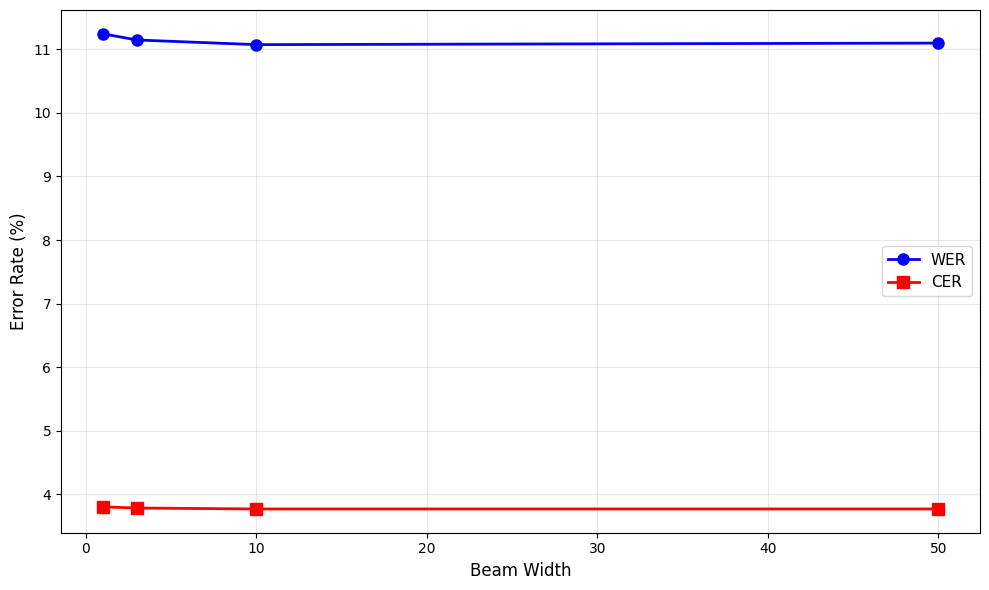

In [50]:
plot_results(results)

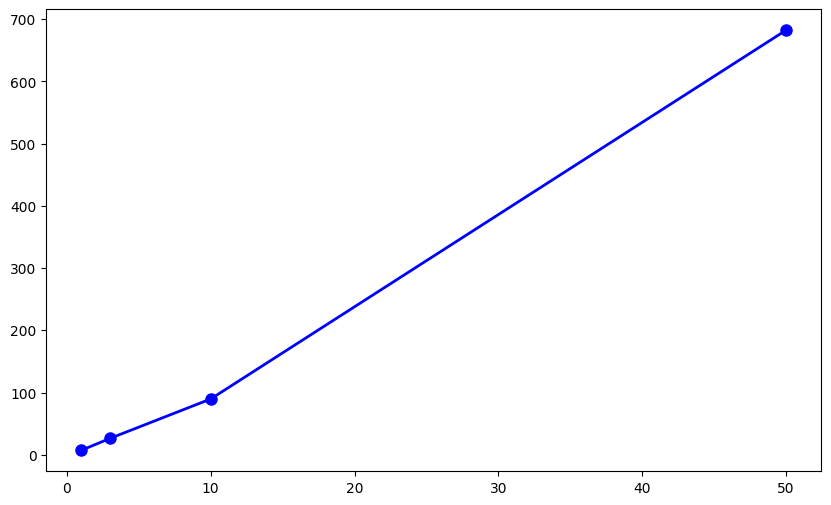

In [51]:
beam_widths = list(results.keys())
times = [r['duration'] for _, r in results.items()]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beam_widths, times, 'b-o', label='Time', linewidth=2, markersize=8)
plt.show();

In [52]:
# saving results for task 7
beam_width = 10
decoder = Wav2Vec2Decoder(beam_width=beam_width)
beam_wer_avg, beam_cer_avg = test_decoder(decoder, manifest, 'beam')
libri_results['Beam search'] = {'LibriSpeech WER': beam_wer_avg, 'LibriSpeech CER': beam_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

# Task 3 (greedy temp sweep)

In [53]:
wer_list = []
cer_list = []
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
for temp in temperatures:
  decoder = Wav2Vec2Decoder(temperature=temp)

  wer_avg, cer_avg = test_decoder(decoder, manifest, 'greedy')
  print(f'temperature = {temp} | wer={np.round(wer_avg, 4)}% | {np.round(cer_avg, 4)}%')
  wer_list.append(wer_avg)
  cer_list.append(cer_avg)

  0%|          | 0/200 [00:00<?, ?it/s]

temperature = 0.5 | wer=11.2198% | 3.8128%


  0%|          | 0/200 [00:00<?, ?it/s]

temperature = 0.8 | wer=11.2198% | 3.8128%


  0%|          | 0/200 [00:00<?, ?it/s]

...

temperature = 1.2 | wer=11.2198% | 3.8128%


  0%|          | 0/200 [00:00<?, ?it/s]

temperature = 1.5 | wer=11.2198% | 3.8128%


  0%|          | 0/200 [00:00<?, ?it/s]

temperature = 2.0 | wer=11.2198% | 3.8128%


no graphs, too obvious result. metrics is consts

# Task 4 (beam lm)

In [54]:
wer_list = []
cer_list = []
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]
results_beam_lm = []
for alpha, beta in tqdm(product(alphas, betas), total=len(alphas)*len(betas)):
  decoder = Wav2Vec2Decoder(
      beam_width=10,
      temperature=1.0,
      alpha=alpha,
      beta=beta)

  wer_avg, cer_avg = test_decoder(decoder, manifest, 'beam_lm')
  print(f'alpha={alpha}, beta={beta} | wer={np.round(wer_avg, 4)}% | {np.round(cer_avg, 4)}%')

  results_beam_lm.append({
      'alpha': alpha,
      'beta': beta,
      'wer': wer_avg,
      'cer': cer_avg,
      })

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

alpha=0.01, beta=0.0 | wer=10.9998% | 3.7595%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=0.01, beta=0.5 | wer=10.9998% | 3.7401%


...

alpha=5.0, beta=0.5 | wer=99.1934% | 89.3028%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=5.0, beta=1.0 | wer=99.1445% | 88.0965%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=5.0, beta=1.5 | wer=98.9734% | 86.5753%


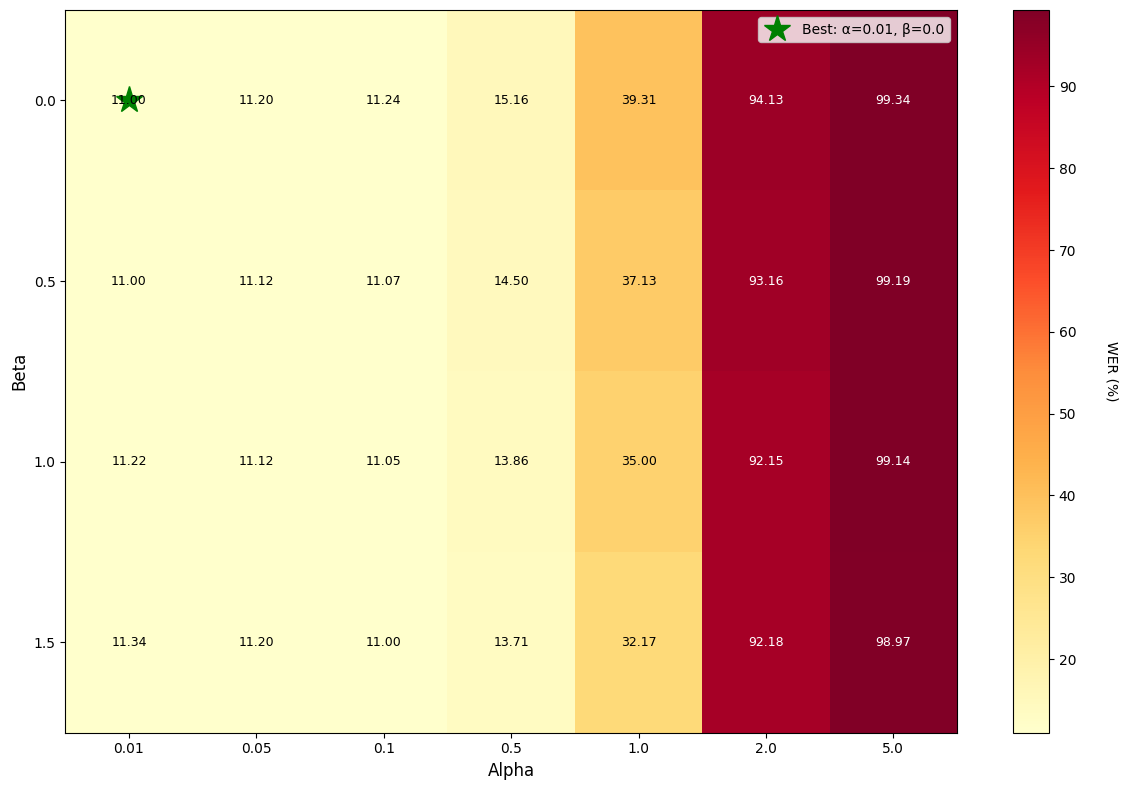

In [55]:
plot_heatmap(results_beam_lm)

In [73]:
print_results_table(results=results_beam_lm, baseline_wer=libri_results['Beam search']['LibriSpeech WER'])

,alpha,beta,wer,cer
0,0.01,0.5,10.999756,3.740129
1,0.01,0.0,10.999756,3.759508
2,0.10,1.5,10.999756,3.783731
3,0.10,1.0,11.048643,3.798266
4,0.10,0.5,11.073087,3.803110
5,0.05,1.0,11.121975,3.783731
6,0.05,0.5,11.121975,3.788576
7,0.05,0.0,11.195307,3.793421
8,0.05,1.5,11.195307,3.793421
9,0.01,1.0,11.219751,3.778887



BEST CONFIGURATION: alpha=0.01, beta=0.5
WER=10.9998%, CER=3.7401%
Absolute improvement over baseline: 0.0733%


In [57]:
# saving results for task 7
decoder = Wav2Vec2Decoder(
    beam_width=10,
    temperature=1.0,
    alpha=0.01,
    beta=0.5)
beam_lm_wer_avg, beam_lm_cer_avg = test_decoder(decoder, manifest, 'beam_lm')
libri_results['Beam + 3-gram (shallow fusion)'] = {'LibriSpeech WER': beam_lm_wer_avg, 'LibriSpeech CER': beam_lm_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

# Task 5 (best beam lm and 4-gram lm)

In [58]:
alpha = 0.01
beta = 0.5

In [59]:
decoder_4_gram = Wav2Vec2Decoder(
    lm_model_path='lm/4-gram.arpa.gz',
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta
    )

In [60]:
start_time = time()
beam_lm_4gram_wer_avg, beam_lm_4gram_cer_avg = test_decoder(decoder_4_gram, manifest, 'beam_lm')
end_time = time()
dur = end_time = start_time
print(f'wer={np.round(beam_lm_4gram_wer_avg, 4)}% | {np.round(beam_lm_4gram_cer_avg, 4)}% | duration={np.round(dur, 2)} sec')
# for sample in tqdm(manifest, total=len(manifest)):
#   wer, cer = cache_test(
#       decoder=decoder_4_gram,
#       audio_path=sample['cache_file'],
#       reference=sample['reference'],
#       method='beam_lm'
#       )
#   wer_avg += wer
#   cer_avg += cer

# end_time = time()
# duration = end_time - start_time

# wer_avg = wer_avg / len(ex_1) * 100
# cer_avg = cer_avg / len(ex_1) * 100

# print(f'avg wer = {np.round(wer_avg, 3)}%')
# print(f'avg cer = {np.round(cer_avg, 3)}%')
# print(f'decoding duration = {np.round(duration, 3)} seconds ({np.round(duration / 60, 3)} minutes)')

  0%|          | 0/200 [00:00<?, ?it/s]

wer=10.9753% | 3.7353% | duration=1774527912.1 sec


# Task 6 (lm rescore)

In [61]:
wer_list = []
cer_list = []
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]
results_rescore = []
for alpha, beta in tqdm(product(alphas, betas), total=len(alphas)*len(betas)):
  decoder = Wav2Vec2Decoder(
      beam_width=10,
      temperature=1.0,
      alpha=alpha,
      beta=beta)
  wer_avg, cer_avg = test_decoder(decoder, manifest, 'beam_lm_rescore')

  print(f'alpha={alpha}, beta={beta} | wer={np.round(wer_avg, 4)}% | {np.round(cer_avg, 4)}%')

  results_rescore.append({
      'alpha': alpha,
      'beta': beta,
      'wer': wer_avg,
      'cer': cer_avg,
      })

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

alpha=0.01, beta=0.0 | wer=11.0486% | 3.7692%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=0.01, beta=0.5 | wer=10.9998% | 3.7547%


...

alpha=5.0, beta=0.5 | wer=12.6131% | 4.0793%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=5.0, beta=1.0 | wer=12.6131% | 4.0793%


  0%|          | 0/200 [00:00<?, ?it/s]

alpha=5.0, beta=1.5 | wer=12.5642% | 4.0744%


In [75]:
print_results_table(results=results_rescore, baseline_wer=libri_results['Beam + 3-gram (shallow fusion)']['LibriSpeech WER'])

Absolute improvement over baseline: 0.0978%

BEST CONFIGURATION: alpha=0.05, beta=1.5
WER=10.902%, CER=3.7401%


,alpha,beta,wer,cer
0,0.05,1.5,10.901980,3.740129
1,0.01,1.5,10.999756,3.749818
2,0.01,0.5,10.999756,3.754663
3,0.10,1.5,10.999756,3.788576
4,0.01,0.0,11.048643,3.769197
5,0.10,1.0,11.048643,3.793421
6,0.05,1.0,11.073087,3.769197
7,0.01,1.0,11.097531,3.764353
8,0.05,0.5,11.097531,3.778887
9,0.05,0.0,11.170863,3.788576


In [25]:
alpha = 0.01
beta = 0.5
decoder_rescore = Wav2Vec2Decoder(
    beam_width=10,
    alpha=0.05,
    beta=1.5)
decoder_shallow = Wav2Vec2Decoder(
    beam_width=10,
    alpha=0.01,
    beta=0.5)

error_count = 0
flag = 0
print('==== starting ====\n')
for ex in manifest:
  beam_out = decoder_rescore.decode_from_cache(ex['cache_file'], method='beam')
  sf_out = decoder_shallow.decode_from_cache(ex['cache_file'], method='beam_lm')
  rs_out = decoder_rescore.decode_from_cache(ex['cache_file'], method='beam_lm_rescore')
  if rs_out == ex['reference'] and sf_out != ex['reference']:
    flag = 1
  if (sf_out != beam_out or rs_out != beam_out) and (error_count < 5 or not flag):
    error_count += 1
    print(f'REF:  {ex['reference']}')
    print(f'BEAM: {beam_out}   | {'correct' if beam_out == ex['reference'] else 'error'}')
    print(f'SF:   {sf_out}   | {'correct' if sf_out == ex['reference'] else 'error'}')
    print(f'RS:   {rs_out}   | {'correct' if rs_out == ex['reference'] else 'error'}\n')
  if error_count > 5 and flag:
    break

==== starting ====

REF:  then as archy stood in the dark literally aghast with astonishment he heard the faint rustling once more and again all was silent
BEAM: then as archi stood in the dark literally aghased with astonishment he heard the faint rustling once more and again all was silent   | error
SF:   then as arche stood in the dark literally aghased with astonishment he heard the faint rustling once more and again all was silent   | error
RS:   then as arche stood in the dark literally aghased with astonishment he heard the faint rustling once more and again all was silent   | error

REF:  the kick he had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly as he could
BEAM: the kickhe had received was a foretaste of what he might expect and after a little consideration he came to the conclusion that his duty was to escape and get back to the cutter as quickly

In [29]:
decoder_rescore = Wav2Vec2Decoder(
    beam_width=10,
    alpha=0.05,
    beta=1.5)
decoder_shallow = Wav2Vec2Decoder(
    beam_width=10,
    alpha=0.01,
    beta=0.5)

print('==== starting ====\n')
for ex in manifest:
  beam_out = decoder_rescore.decode_from_cache(ex['cache_file'], method='beam')
  sf_out = decoder_shallow.decode_from_cache(ex['cache_file'], method='beam_lm')
  rs_out = decoder_rescore.decode_from_cache(ex['cache_file'], method='beam_lm_rescore')
  if sf_out != beam_out and rs_out == beam_out:
    print(f'REF:  {ex['reference']}')
    print(f'BEAM: {beam_out}   | {'correct' if beam_out == ex['reference'] else 'error'}')
    print(f'SF:   {sf_out}   | {'correct' if sf_out == ex['reference'] else 'error'}')
    print(f'RS:   {rs_out}   | {'correct' if rs_out == ex['reference'] else 'error'}\n')
    break

==== starting ====

REF:  he swung round walked aft and began sweeping the shore again with his glass while the master and dick exchanged glances which meant a great deal
BEAM: he swung round walked aff and began sweeping the shore again with his glass while the master and dick exchanged glances which met agree deal   | error
SF:   he swung round walked aff and began sweeping the shore again with his glass while the master and dick exchanged glances which met a gree deal   | error
RS:   he swung round walked aff and began sweeping the shore again with his glass while the master and dick exchanged glances which met agree deal   | error



In [64]:
# saving results for task 7
decoder = Wav2Vec2Decoder(
    beam_width=10,
    temperature=1.0,
    alpha=0.01,
    beta=0.5)
beam_lm_rescore_wer_avg, beam_lm_rescore_cer_avg = test_decoder(decoder, manifest, 'beam_lm_rescore')
libri_results['Beam + 3-gram (rescoring)'] = {'LibriSpeech WER': beam_lm_rescore_wer_avg, 'LibriSpeech CER': beam_lm_rescore_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

# Task 7 (earnings22_test)

In [76]:
earnings_result = {}

## greedy

In [77]:
decoder = Wav2Vec2Decoder()

In [78]:
greedy_wer_avg, greedy_cer_avg = test_decoder(decoder, manifest_earnings, 'greedy')
print(f'greedy avg wer = {np.round(greedy_wer_avg, 4)}%')
print(f'greedy avg cer = {np.round(greedy_cer_avg, 4)}%')

earnings_result['Greedy'] = {'Earnings22 WER': greedy_wer_avg, 'Earnings22 CER': greedy_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

greedy avg wer = 54.9699%
greedy avg cer = 25.5785%


## beam

In [79]:
beam_width = 10
decoder = Wav2Vec2Decoder(beam_width=beam_width)

beam_wer_avg, beam_cer_avg = test_decoder(decoder, manifest_earnings, 'beam')
print(f'beam avg wer = {np.round(beam_wer_avg, 4)}%')
print(f'beam avg cer = {np.round(beam_cer_avg, 4)}%')

earnings_result['Beam search'] = {'Earnings22 WER': beam_wer_avg, 'Earnings22 CER': beam_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

beam avg wer = 54.9398%
beam avg cer = 25.3839%


## shallow fusion

In [80]:
alpha = 0.01
beta = 0.5
decoder = Wav2Vec2Decoder(
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta)

beam_lm_wer_avg, beam_lm_cer_avg = test_decoder(decoder, manifest_earnings, 'beam_lm')

print(f'beam lm avg wer = {np.round(beam_lm_wer_avg, 4)}%')
print(f'beam lm avg cer = {np.round(beam_lm_cer_avg, 4)}%')

earnings_result['Beam + 3-gram (shallow fusion)'] = {'Earnings22 WER': beam_lm_wer_avg, 'Earnings22 CER': beam_lm_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

beam lm avg wer = 55.5723%
beam lm avg cer = 25.4163%


## rescoring

In [69]:
alpha = 0.01
beta = 0.5

decoder = Wav2Vec2Decoder(
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta)

rescoring_wer_avg, rescoring_lm_cer_avg = test_decoder(decoder, manifest_earnings, 'beam_lm_rescore')

print(f'beam lm rescoring avg wer = {np.round(rescoring_wer_avg, 4)}%')
print(f'beam lm rescoring avg cer = {np.round(rescoring_lm_cer_avg, 4)}%')

earnings_result['Beam + 3-gram (rescoring)'] = {'Earnings22 WER': rescoring_wer_avg, 'Earnings22 CER': rescoring_lm_cer_avg}

  0%|          | 0/200 [00:00<?, ?it/s]

beam lm rescoring avg wer = 55.0602%
beam lm rescoring avg cer = 25.4055%


## result

In [82]:
libri_results_df = pd.DataFrame(libri_results).T
libri_results_df.index.name = 'Method'
earnings_result_df = pd.DataFrame(earnings_result).T
earnings_result_df.index.name = 'Method'

In [83]:
results_df = libri_results_df.merge(earnings_result_df, left_index=True, right_index=True)

In [84]:
results_df

,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
Method,,,,
Greedy,11.219751,3.812800,54.969880,25.578503
Beam search,11.073087,3.769197,54.939759,25.383867
Beam + 3-gram (shallow fusion),10.999756,3.740129,55.572289,25.416306
Beam + 3-gram (rescoring),10.999756,3.754663,55.060241,25.405493


# Task 7b (temp vs earnings)

In [85]:
temperatures = [0.5, 1.0, 1.5, 2.0]
alpha = 0.1
beta = 0.5
greedy_temp_wers = []
beam_lm_temp_wers = []
for temp in temperatures:
    decoder = Wav2Vec2Decoder(
        beam_width=10,
        temperature=temp,
        alpha=alpha,
        beta=beta
        )
    greedy_temp_wer, _ = test_decoder(decoder, manifest_earnings, 'greedy')
    beam_lm_temp_wer, _ = test_decoder(decoder, manifest_earnings, 'beam_lm')
    greedy_temp_wers.append(greedy_temp_wer)
    beam_lm_temp_wers.append(beam_lm_temp_wer)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

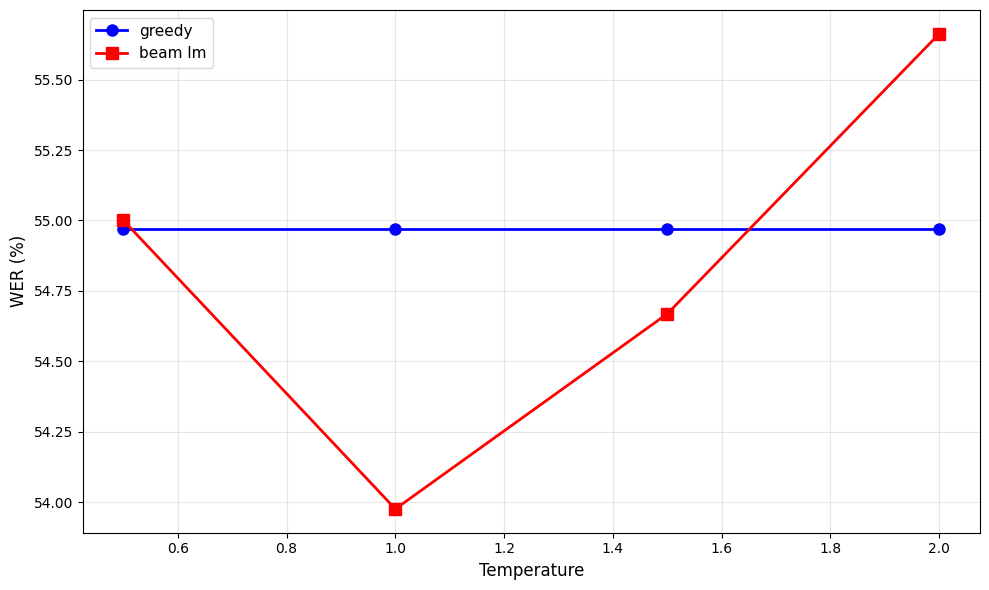

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(temperatures, greedy_temp_wers, 'b-o', label='greedy', linewidth=2, markersize=8)
ax.plot(temperatures, beam_lm_temp_wers, 'r-s', label='beam lm', linewidth=2, markersize=8)


ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel('WER (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 8 (training LM)

In [35]:
!sudo apt-get update -y
!sudo apt-get install cmake libboost-all-dev -y

!git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build

!mkdir -p /tmp/kenlm_build/build
%cd /tmp/kenlm_build/build

!cmake ..
!make -j4 lmplz build_binary

%cd /content

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,927 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,011 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,618 kB]
Get:14 http://archiv

In [36]:
import re
from num2words import num2words

def clean_financial_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\'\s0-9]', ' ', text)

    def replace_num(match):
        try:
            return num2words(int(match.group()))
        except:
            return match.group()

    text = re.sub(r'\d+', replace_num, text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [42]:
!touch extended_corpus.txt
output_corpus = 'data/extended_corpus.txt'
with open(output_corpus, "w", encoding="utf-8") as outfile:
  extend_text = new_fin_data['Content'].to_list()
  for line in tqdm(extend_text, total=len(extend_text)):
    clean_line = clean_financial_text(line)
    if clean_line:
      outfile.write(clean_line + "\n")

  for split_type in ['train', 'validation', 'test']:
    extend_text = pd.DataFrame(phrasebank_ds[split_type])['sentence'].to_list()
    for line in tqdm(extend_text, total=len(extend_text)):
      clean_line = clean_financial_text(line)
      if clean_line:
        outfile.write(clean_line + "\n")

  for line in tqdm(ratings.to_list(), total=len(ratings)):
    clean_line = clean_financial_text(line)
    if clean_line:
      outfile.write(clean_line + "\n")
  with open('data/earnings22_train/corpus.txt', "r", encoding="utf-8") as infile:
    print('starting preparing original corpus')
    for line in infile:
      clean_line = clean_financial_text(line)
      if clean_line:
        outfile.write(clean_line + "\n")

  0%|          | 0/15534 [00:00<?, ?it/s]

  0%|          | 0/3100 [00:00<?, ?it/s]

  0%|          | 0/776 [00:00<?, ?it/s]

  0%|          | 0/970 [00:00<?, ?it/s]

  0%|          | 0/1400469 [00:00<?, ?it/s]

starting preparing original corpus


In [43]:
!/tmp/kenlm_build/build/bin/lmplz -o 3 --discount_fallback < data/extended_corpus.txt > /tmp/financial-3gram.arpa

!gzip -c /tmp/financial-3gram.arpa > lm/financial-3gram.arpa.gz

=== 1/5 Counting and sorting n-grams ===
Reading /content/data/extended_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 19951333 types 122652
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:1471824 2:3785457408 3:7097732608
Statistics:
1 122652 D1=0.655686 D2=1.02882 D3+=1.3384
2 1837223 D1=0.767017 D2=1.08937 D3+=1.34383
3 4607806 D1=0.685756 D2=1.16016 D3+=1.41529
Memory estimate for binary LM:
type     MB
probing 124 assuming -p 1.5
probing 135 assuming -r models -p 1.5
trie     51 without quantization
trie     28 assuming -q 8 -b 8 quantization 
trie     48 assuming -a 22 array pointer compression
trie     25 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:1471824 2:29395568 3:92156120
----5---1

In [44]:
# checking if file was created
!ls -lh lm/

total 1.4G
-rw-r--r-- 1 root root  33M Mar 18 20:31 3-gram.pruned.1e-7.arpa.gz
-rw-r--r-- 1 root root 1.3G Mar 24 15:03 4-gram.arpa.gz
-rw-r--r-- 1 root root  65M Mar 26 21:25 financial-3gram.arpa.gz


In [105]:
alpha = 0.01
beta = 0.5

decoder = Wav2Vec2Decoder(
    lm_model_path="lm/financial-3gram.arpa.gz",
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta)

In [54]:
new_lm_results_earn = {}

In [107]:
new_beam_lm_wer_avg, new_beam_lm_cer_avg = test_decoder(decoder, manifest_earnings, 'beam_lm')

print(f'new LM beam lm avg wer = {np.round(new_beam_lm_wer_avg, 4)}%')
print(f'new LM beam lm avg cer = {np.round(new_beam_lm_cer_avg, 4)}%')

new_lm_results_earn['Beam + 3-gram (shallow fusion)'] = {
    'Earnings22 WER': new_beam_lm_wer_avg,
    'Earnings22 CER': new_beam_lm_cer_avg
    }

  0%|          | 0/200 [00:00<?, ?it/s]

new LM beam lm avg wer = 55.3614%
new LM beam lm avg cer = 25.4325%


In [45]:
alpha = 0.05
beta = 1.5

decoder_rescore = Wav2Vec2Decoder(
    lm_model_path="lm/financial-3gram.arpa.gz",
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta)

In [46]:
new_beam_lm_rescore_wer_avg, new_beam_lm_rescore_cer_avg = test_decoder(decoder_rescore, manifest_earnings, 'beam_lm_rescore')

print(f'new LM beam rescore lm avg wer = {np.round(new_beam_lm_rescore_wer_avg, 4)}%')
print(f'new LM beam rescore lm avg cer = {np.round(new_beam_lm_rescore_cer_avg, 4)}%')

new_lm_results_earn['Beam + 3-gram (rescoring)'] = {
    'Earnings22 WER': new_beam_lm_rescore_wer_avg,
    'Earnings22 CER': new_beam_lm_rescore_cer_avg
    }

  0%|          | 0/200 [00:00<?, ?it/s]

new LM beam rescore lm avg wer = 55.1807%
new LM beam rescore lm avg cer = 25.3893%


In [109]:
test_ex = manifest_earnings[:7]
for ex in test_ex:
  greedy_out = decoder.decode_from_cache(ex['cache_file'], method='greedy')
  beam_out = decoder.decode_from_cache(ex['cache_file'], method='beam')
  sf_out = decoder.decode_from_cache(ex['cache_file'], method='beam_lm')
  rs_out = decoder.decode_from_cache(ex['cache_file'], method='beam_lm_rescore')
  print(f'REF:    {ex["reference"]}')
  print(f'GREEDY: {greedy_out}')
  print(f'BEAM:   {beam_out}')
  print(f'SF:     {sf_out}')
  print(f'RS:     {rs_out}\n')

REF:    but happy with what we've been seeing here
GREEDY: wile heaby bith what bes bin seeing he
BEAM:   wile heaby bith what beas bin seeing he
SF:     wile heaby bith what beas bin seeing he
RS:     wile heaby bith what beas bin seeing he

REF:    i just just curious to get your sense on on kind of visibility of of this business because it's obviously been very q4 loaded over the last couple of years
GREEDY: i just just curious to get your san song on paate visibility off of this business cause it's always have been very cufourloaded over the last couple of years om
BEAM:   i just just curious to get your san song on paathe visibility of of this business cause it's always have been very cufoureloaded over the last couple of years om
SF:     i just just curious to get your san song on paa the visibility of of this business cause it's always have been very cufoureloaded over the last couple of years om
RS:     i just just curious to get your san song on paa the visibility of of this b

In [51]:
new_lm_results_libri = {}

In [111]:
new_beam_lm_wer_avg, new_beam_lm_cer_avg = test_decoder(decoder, manifest, 'beam_lm')

print(f'new LM beam libri lm avg wer = {np.round(new_beam_lm_wer_avg, 4)}%')
print(f'new LM beam libri lm avg cer = {np.round(new_beam_lm_cer_avg, 4)}%')

new_lm_results_libri['Beam + 3-gram (shallow fusion)'] = {
    'LibriSpeech WER': new_beam_lm_wer_avg,
    'LibriSpeech CER': new_beam_lm_cer_avg
    }

  0%|          | 0/200 [00:00<?, ?it/s]

new LM beam libri lm avg wer = 11.0242%
new LM beam libri lm avg cer = 3.7498%


In [48]:
alpha = 0.05
beta = 1.5

decoder_rescore = Wav2Vec2Decoder(
    lm_model_path="lm/financial-3gram.arpa.gz",
    beam_width=10,
    temperature=1.0,
    alpha=alpha,
    beta=beta)

In [49]:
new_beam_lm_rescore_wer_avg, new_beam_lm_rescore_cer_avg = test_decoder(decoder_rescore, manifest, 'beam_lm_rescore')

print(f'new LM beam rescore libri lm avg wer = {np.round(new_beam_lm_rescore_wer_avg, 4)}%')
print(f'new LM beam rescore libri lm avg cer = {np.round(new_beam_lm_rescore_cer_avg, 4)}%')

new_lm_results_libri['Beam + 3-gram (rescoring)'] = {
    'LibriSpeech WER': new_beam_lm_rescore_wer_avg,
    'LibriSpeech CER': new_beam_lm_rescore_cer_avg
    }

  0%|          | 0/200 [00:00<?, ?it/s]

new LM beam rescore libri lm avg wer = 10.9998%
new LM beam rescore libri lm avg cer = 3.7498%


In [67]:
new_lm_results_libri_df = pd.DataFrame(new_lm_results_libri).T
new_lm_results_libri_df.index.name = 'Method'
new_lm_results_earn_df = pd.DataFrame(new_lm_results_earn).T
new_lm_results_earn_df.index.name = 'Method'

new_lm_result_df = new_lm_results_libri_df.merge(new_lm_results_earn_df, left_index=True, right_index=True)


In [68]:
new_lm_result_df

,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
Method,,,,
Beam + 3-gram (rescoring),10.999756,3.749818,55.180723,25.389273
Beam + 3-gram (shallow fusion),11.024199,3.749818,55.361446,25.432526
